# Survival analysis

In [1]:
# Load basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# pip install lifelines


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df =  pd.read_csv("F:/Kaggle_competitions/Breast_cancer_survival/breast_cancer_survival.csv")
df

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.952560,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.000000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.523030,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.876180,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.226110,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,59,FEMALE,0.024598,1.40050,0.024751,0.280320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,15-Jan-19,27-Mar-20,Alive
330,41,FEMALE,0.100120,-0.46547,0.472370,-0.523870,I,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Modified Radical Mastectomy,25-Jul-18,23-Apr-19,Alive
331,54,FEMALE,0.753820,1.64250,-0.332850,0.857860,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Simple Mastectomy,26-Mar-19,11-Oct-19,Dead
332,74,FEMALE,0.972510,1.42680,-0.366570,-0.107820,II,Infiltrating Lobular Carcinoma,Positive,Positive,Negative,Lumpectomy,26-Nov-18,05-Dec-18,Alive


In [4]:
df.describe()

,Age,Protein1,Protein2,Protein3,Protein4
count,334.000000,334.000000,334.000000,334.000000,334.000000
mean,58.886228,-0.029991,0.946896,-0.090204,0.009819
std,12.961212,0.563588,0.911637,0.585175,0.629055
min,29.000000,-2.340900,-0.978730,-1.627400,-2.025500
25%,49.000000,-0.358888,0.362173,-0.513748,-0.377090
50%,58.000000,0.006129,0.992805,-0.173180,0.041768
75%,68.000000,0.343598,1.627900,0.278353,0.425630
max,90.000000,1.593600,3.402200,2.193400,1.629900


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    object 
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    object 
 7   Histology           334 non-null    object 
 8   ER status           334 non-null    object 
 9   PR status           334 non-null    object 
 10  HER2 status         334 non-null    object 
 11  Surgery_type        334 non-null    object 
 12  Date_of_Surgery     334 non-null    object 
 13  Date_of_Last_Visit  317 non-null    object 
 14  Patient_Status      321 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 39.3+ K

In [6]:
df.isna().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [8]:
df.columns

Index(['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4',
       'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status',
       'Surgery_type', 'Date_of_Surgery', 'Date_of_Last_Visit',
       'Patient_Status'],
      dtype='object')

In [11]:
# Drop na

df = df.dropna(subset=[
    "Date_of_Surgery",
    "Date_of_Last_Visit",
    "Patient_Status"
])

df.isna().sum()

Age                   0
Gender                0
Protein1              0
Protein2              0
Protein3              0
Protein4              0
Tumour_Stage          0
Histology             0
ER status             0
PR status             0
HER2 status           0
Surgery_type          0
Date_of_Surgery       0
Date_of_Last_Visit    0
Patient_Status        0
dtype: int64

In [16]:
# Convert Dates and Create Survival Time

df["Date_of_Surgery"] = pd.to_datetime(df["Date_of_Surgery"])
df["Date_of_Last_Visit"] = pd.to_datetime(df["Date_of_Last_Visit"])

df["Survival_Time"] = (
    df["Date_of_Last_Visit"] - df["Date_of_Surgery"]
).dt.days

df["Date_of_Surgery"].head()


0   2018-05-20
1   2018-04-26
2   2018-08-24
3   2018-11-16
4   2018-12-12
Name: Date_of_Surgery, dtype: datetime64[ns]

In [17]:
# Convert Dates With Format
df["Date_of_Surgery"] = pd.to_datetime(df["Date_of_Surgery"], format="%d/%m/%Y")
df["Date_of_Last_Visit"] = pd.to_datetime(df["Date_of_Last_Visit"], format="%d/%m/%Y")

df["Date_of_Last_Visit"].head()

0   2018-08-26
1   2019-01-25
2   2020-04-08
3   2020-07-28
4   2019-01-05
Name: Date_of_Last_Visit, dtype: datetime64[ns]

In [20]:
# Create Survival Time

df["Survival_Time"] = (df["Date_of_Last_Visit"] - df["Date_of_Surgery"]).dt.days

df["Survival_Time"].describe()

count     317.000000
mean      447.776025
std       386.279467
min         0.000000
25%       189.000000
50%       372.000000
75%       595.000000
max      3019.000000
Name: Survival_Time, dtype: float64

# Inference:

| Statistic         | Interpretation                            |
| ----------------- | ----------------------------------------- |
| Mean ≈ 448 days   | Average follow-up ~1.2 years              |
| Median ≈ 372 days | Half survived ~1 year                     |
| Max = 3019 days   | ~8 years follow-up                        |
| Min = 0 days      | Some patients died or last visit same day |


In [21]:
df[df["Survival_Time"] < 0]

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status,Survival_Time


In [23]:
# Create event column

df["Event"] = df["Patient_Status"].map({
    "Alive": 0,
    "Dead": 1
})

df[["Patient_Status","Event"]].value_counts()

Patient_Status  Event
Alive           0        255
Dead            1         62
Name: count, dtype: int64

# Inference:

| Status           | Count |
| ---------------- | ----- |
| Alive (censored) | 255   |
| Dead (event)     | 62    |
| Total            | 317   |

So only ~19.5% events (deaths) and ~80% censored.
This is actually very common in survival datasets.

But this has an important implication:

Your dataset is imbalanced for ML, but fine for survival analysis.

So:
Kaplan–Meier → OK
Cox model → OK
ML classification → must handle imbalance

# Survival analysis :

# Kaplan–Meier Interpretation

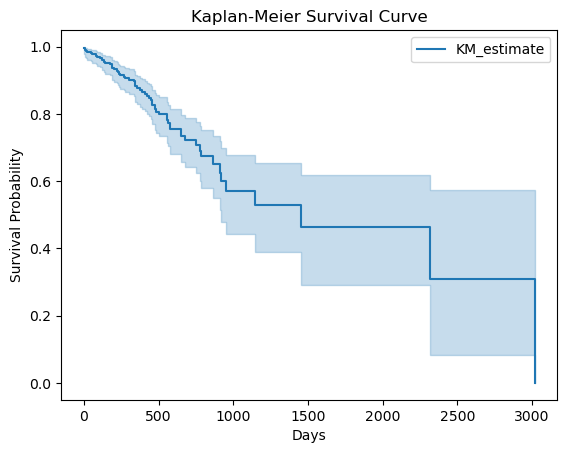

medain_survival_time :  1455.0


In [30]:
# create Kaplan–Meier Object

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(df["Survival_Time"], event_observed=df["Event"])
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.savefig("F:/Kaggle_competitions/Breast_cancer_survival/Kaplan-Meier Survival Curve.jpeg",dpi=300)
plt.show()

print ("medain_survival_time : ",kmf.median_survival_time_)

In [31]:
# Survival Probability at Specific Time Points
print("1-year survival:", kmf.predict(365))
print("3-year survival:", kmf.predict(1095))
print("5-year survival:", kmf.predict(1825))

1-year survival: 0.8769818359757587
3-year survival: 0.5707541382665733
5-year survival: 0.46373773734159096


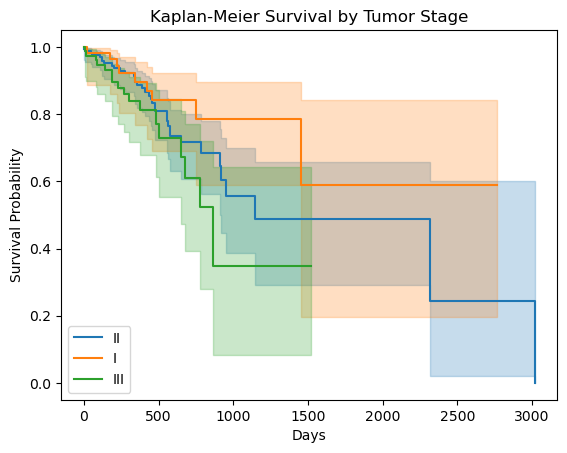

In [32]:
# Survival by Tumor Stage

kmf = KaplanMeierFitter()

plt.figure()

for stage in df["Tumour_Stage"].unique():
    ix = df["Tumour_Stage"] == stage
    kmf.fit(df["Survival_Time"][ix],
            df["Event"][ix],
            label=str(stage))
    kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival by Tumor Stage")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.savefig("F:/Kaggle_competitions/Breast_cancer_survival/Kaplan-Meier_Survival_by_tumour_stage.jpeg",dpi=300)
plt.show()

# Inferfence : 

| Metric          | Value                    |
| --------------- | ------------------------ |
| Median survival | **1455 days (~4 years)** |
| 1-year survival | **0.877 (87.7%)**        |
| 3-year survival | **0.571 (57.1%)**        |
| 5-year survival | **0.464 (46.4%)**        |

1. Kaplan–Meier survival analysis showed that the median survival time of breast cancer patients was approximately 1455 days (~4 years). The estimated 1-year, 3-year, and 5-year survival probabilities were 87.7%, 57.1%, and 46.4%, respectively, indicating a gradual decline in survival probability over time.

2. Kaplan–Meier survival curves stratified by tumor stage showed that patients with Stage I tumors had the highest survival probability, while Stage III patients had the lowest survival probability. Survival probability decreased progressively with increasing tumor stage, indicating that tumor stage is an important prognostic factor for patient survival.

# Analysis already shows:

| Factor                    | Effect                       |
| ------------------------- | ---------------------------- |
| Tumor stage               | Affects survival             |
| Time                      | Survival decreases over time |
| Median survival ~ 4 years | Prognosis                    |
| 5-year survival ~ 46%     | Clinical metric              |


<lifelines.CoxPHFitter: fitted with 317 total observations, 255 right-censored observations>
             duration col = 'Survival_Time'
                event col = 'Event'
                penalizer = 0.2
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 317
number of events observed = 62
   partial log-likelihood = -291.98
         time fit was run = 2026-03-22 05:55:10 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Age          -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Protein1     -0.04      0.96      0.16           -0.35            0.28                0.70                1.32
Protein2      0.10      1.11      0.10           -0.10            0.30                0.91                1.35
Tumour_Stage  0.21      1.23      0.14           -0.07            0.48                0.94                1.61
HER2 status  -0.06      0.94      0.33           -0.71            0.59                0.49                1.81
Surgery_type -0.01      0.99      0.09           -0.18            0.16                0.83                1.18

              cmp to     z    p  -log2(p)
covariate                                
Age             0.00 -0.09 0.93      0.11
Protein1        0.00 -0.23 0.82      0.29
Protein2        0.00  0.99 0.32      1.64
Tumour_Stage    0.00  1.48 0.14      2.86
HER2 status     0.00 -0.17 0.86      0.21
Surgery_type    0.00 -0.11 0.91      0.13
---
Concordance = 0.57
Partial AIC = 595.97
log-likelihood ratio test = 3.19 on 6 df
-log2(p) of ll-ratio test = 0.35

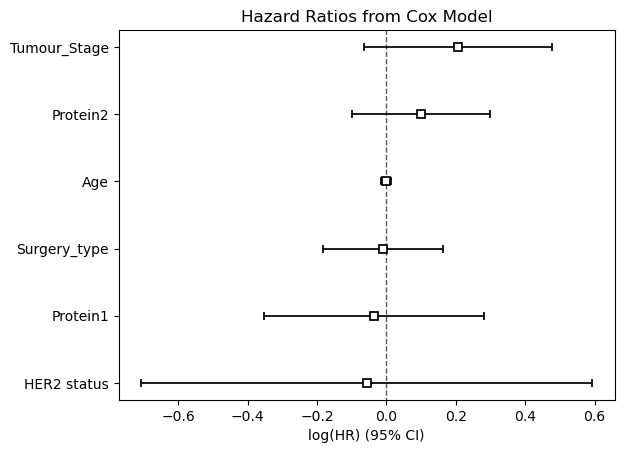

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from sklearn.preprocessing import LabelEncoder

df_cox = df.copy()

# Encode categorical variables
le = LabelEncoder()
categorical_cols = [
    "Gender",
    "Tumour_Stage",
    "HER2 status",
    "Surgery_type"
]

for col in categorical_cols:
    df_cox[col] = le.fit_transform(df_cox[col])

# Select variables (reduce multicollinearity)
df_cox = df_cox[[
    "Age",
    "Protein1",
    "Protein2",
    "Tumour_Stage",
    "HER2 status",
    "Surgery_type",
    "Survival_Time",
    "Event"
]]

# Fit Cox model
cph = CoxPHFitter(penalizer=0.2)
cph.fit(df_cox, duration_col="Survival_Time", event_col="Event")

# Print summary
cph.print_summary()

# Plot hazard ratios
cph.plot()
plt.title("Hazard Ratios from Cox Model")
plt.savefig("F:/Kaggle_competitions/cox model.jpeg",dpi=300)
plt.savefig("F:/Kaggle_competitions/Breast_cancer_survival/cox model_hazard ratios.jpeg",dpi=300)
plt.show()


# Inference :

Cox proportional hazards regression analysis was performed to evaluate the association between clinical variables, protein biomarkers, and patient survival. Tumor stage showed a trend toward increased risk of death (HR = 1.23), although it was not statistically significant. The concordance index of the model was 0.57, indicating modest predictive ability. These results suggest that while clinical and biomarker variables may influence survival, larger datasets are required for robust prognostic modeling.

# Machine learning models

In [39]:
# Prepare data

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Encode categorical variables
le = LabelEncoder()
categorical_cols = [
    "Gender",
    "Tumour_Stage",
    "Histology",
    "ER status",
    "PR status",
    "HER2 status",
    "Surgery_type"
]

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features and target
X = df_ml.drop([
    "Event",
    "Survival_Time",
    "Date_of_Surgery",
    "Date_of_Last_Visit",
    "Patient_Status"
], axis=1)

y = df_ml["Event"]

print(X.shape)

(317, 12)


In [40]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models building

In [47]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Copy dataframe
df_ml = df.copy()

# Encode categorical variables
le = LabelEncoder()
categorical_cols = [
    "Gender",
    "Tumour_Stage",
    "Histology",
    "ER status",
    "PR status",
    "HER2 status",
    "Surgery_type"
]

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features and target
X = df_ml.drop([
    "Event",
    "Survival_Time",
    "Date_of_Surgery",
    "Date_of_Last_Visit",
    "Patient_Status"
], axis=1)

y = df_ml["Event"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}




C:\Users\kiran\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:38:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


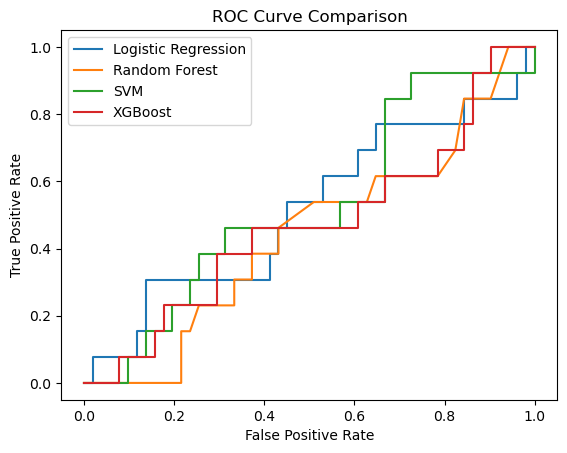


Model Performance:
                     Accuracy   ROC_AUC
Logistic Regression  0.796875  0.517345
Random Forest        0.796875  0.443439
SVM                  0.796875  0.523379
XGBoost              0.750000  0.469080


In [50]:
# Train and evaluate
for name, model in models.items():
    
    if name in ["Random Forest", "XGBoost"]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:,1]
    
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    
    results[name] = [acc, auc]
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

# Plot ROC curves
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Model comparison
results_df = pd.DataFrame(results, index=["Accuracy", "ROC_AUC"]).T
print("\nModel Performance:")
print(results_df)



Feature Importance (XGBoost):
         Feature  Importance
10   HER2 status    0.530075
6   Tumour_Stage    0.081081
7      Histology    0.064674
11  Surgery_type    0.061263
4       Protein3    0.060381
3       Protein2    0.054494
5       Protein4    0.053156
2       Protein1    0.048993
0            Age    0.045882
1         Gender    0.000000
9      PR status    0.000000
8      ER status    0.000000


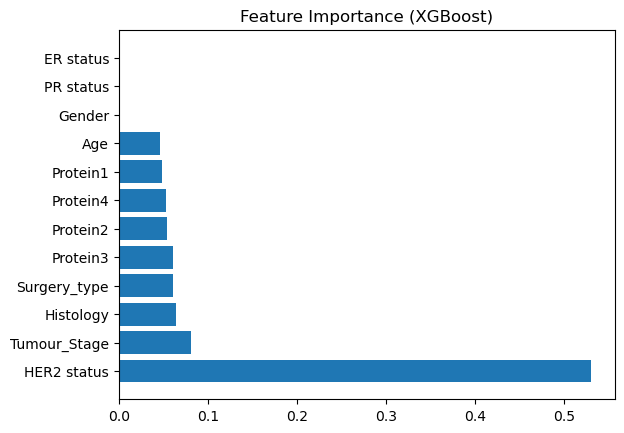

In [51]:
# Feature importance from XGBoost
xgb_model = models["XGBoost"]
importances = xgb_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (XGBoost):")
print(importance_df)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance (XGBoost)")
plt.show()


# Models With Class Weights

In [52]:
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "XGBoost": XGBClassifier(scale_pos_weight=4, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    
    if name in ["Random Forest", "XGBoost"]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:,1]
    
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    
    print("\n", name)
    print("Accuracy:", acc)
    print("ROC AUC:", auc)
    print(classification_report(y_test, pred))


 Logistic Regression
Accuracy: 0.5
ROC AUC: 0.5082956259426847
              precision    recall  f1-score   support

           0       0.81      0.49      0.61        51
           1       0.21      0.54      0.30        13

    accuracy                           0.50        64
   macro avg       0.51      0.51      0.46        64
weighted avg       0.69      0.50      0.55        64


 Random Forest
Accuracy: 0.796875
ROC AUC: 0.46530920060331826
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        51
           1       0.00      0.00      0.00        13

    accuracy                           0.80        64
   macro avg       0.40      0.50      0.44        64
weighted avg       0.64      0.80      0.71        64


 SVM
Accuracy: 0.625
ROC AUC: 0.5942684766214178
              precision    recall  f1-score   support

           0       0.81      0.69      0.74        51
           1       0.24      0.38      0.29        13

    

C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 XGBoost
Accuracy: 0.765625
ROC AUC: 0.4932126696832579
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        51
           1       0.38      0.23      0.29        13

    accuracy                           0.77        64
   macro avg       0.60      0.57      0.57        64
weighted avg       0.73      0.77      0.74        64



# Inference :

| Model         | Accuracy | ROC AUC  | Dead Recall |
| ------------- | -------- | -------- | ----------- |
| Logistic      | 0.50     | 0.51     | **0.54**    |
| Random Forest | 0.80     | 0.46     | 0.00        |
| SVM           | 0.62     | **0.59** | 0.38        |
| XGBoost       | 0.77     | 0.49     | 0.23        |


Machine learning models were developed to predict patient survival using clinical and protein biomarker data. Among the models tested, Support Vector Machine showed the best performance with a ROC-AUC of 0.59. Random Forest and XGBoost models showed higher accuracy due to class imbalance but failed to correctly predict deceased patients. Logistic regression showed moderate recall for the deceased class but overall low predictive performance. The relatively low model performance may be due to small dataset size and limited number of predictive biomarkers.


# Hyperparameter Tuning for SVM

In [61]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    average_precision_score
)

# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

svm = SVC(probability=True, class_weight='balanced')

# Grid Search with CV
grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)

# Best model
best_svm = grid.best_estimator_

# Cross-validation on training set with best model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("\nCross Validation ROC AUC scores:", cv_scores)
print("Mean CV ROC AUC:", cv_scores.mean())

# Test set evaluation
y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)[:,1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\nTest Set Performance:")
print("Accuracy:", acc)
print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV ROC AUC: 0.5470447154471545

Cross Validation ROC AUC scores: [0.35853659 0.63170732 0.68780488 0.60162602 0.5325    ]
Mean CV ROC AUC: 0.5624349593495934

Test Set Performance:
Accuracy: 0.625
ROC AUC: 0.5942684766214178
PR AUC: 0.24886364308096215

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.69      0.74        51
           1       0.24      0.38      0.29        13

    accuracy                           0.62        64
   macro avg       0.53      0.54      0.52        64
weighted avg       0.70      0.62      0.65        64



In [63]:
# Evaluate

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Predictions
y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("Accuracy:", acc)
print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.625
ROC AUC: 0.5942684766214178
PR AUC: 0.24886364308096215

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.69      0.74        51
           1       0.24      0.38      0.29        13

    accuracy                           0.62        64
   macro avg       0.53      0.54      0.52        64
weighted avg       0.70      0.62      0.65        64



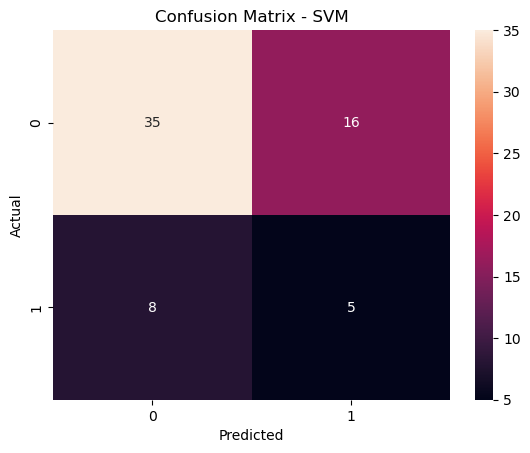

In [64]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

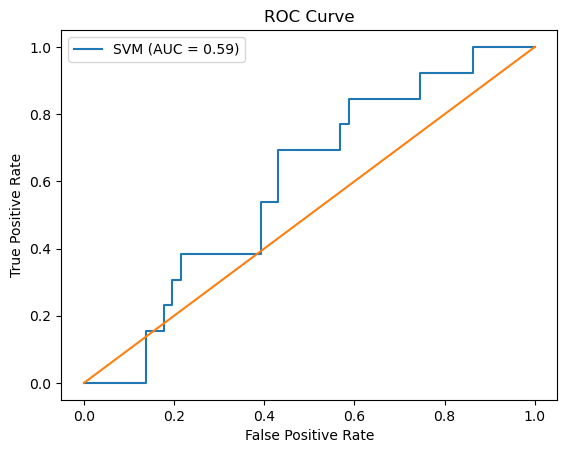

In [65]:
# ROC CURVE

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

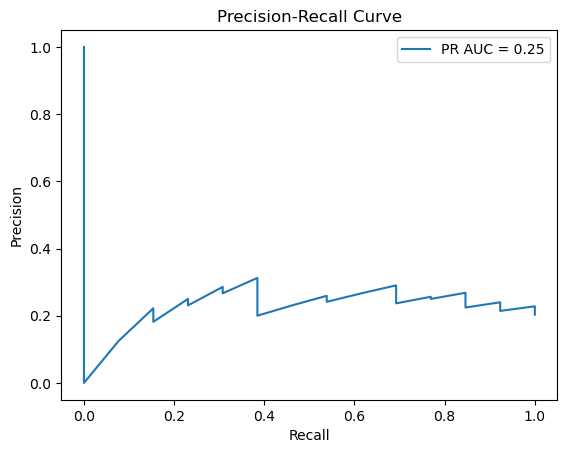

In [66]:
# Precision–Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

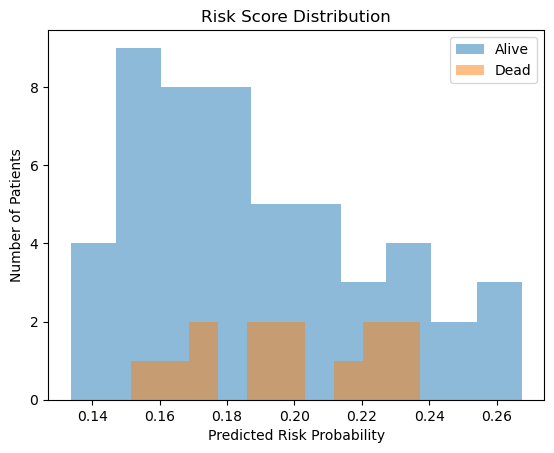

In [67]:
# Risk Score Distribution

plt.figure()
plt.hist(y_prob[y_test==0], alpha=0.5, label="Alive")
plt.hist(y_prob[y_test==1], alpha=0.5, label="Dead")
plt.xlabel("Predicted Risk Probability")
plt.ylabel("Number of Patients")
plt.title("Risk Score Distribution")
plt.legend()
plt.show()

In [68]:
# Model Performance Summary Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "PR AUC"],
    "Value": [acc, roc_auc, pr_auc]
})

print(metrics_df)

     Metric     Value
0  Accuracy  0.625000
1   ROC AUC  0.594268
2    PR AUC  0.248864


In [70]:
# K stratified validation

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = []
acc_scores = []
pr_scores = []

for train_idx, val_idx in cv.split(X_train_scaled, y_train):
    
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    best_svm.fit(X_tr, y_tr)
    
    y_prob = best_svm.predict_proba(X_val)[:,1]
    y_pred = best_svm.predict(X_val)
    
    roc_scores.append(roc_auc_score(y_val, y_prob))
    acc_scores.append(accuracy_score(y_val, y_pred))
    pr_scores.append(average_precision_score(y_val, y_prob))

print("CV ROC AUC:", np.mean(roc_scores))
print("CV Accuracy:", np.mean(acc_scores))
print("CV PR AUC:", np.mean(pr_scores))

CV ROC AUC: 0.5624349593495934
CV Accuracy: 0.6287058823529412
CV PR AUC: 0.2814600247863338


# Inference :

| Metric           | Value     | Interpretation                   |
| ---------------- | --------- | -------------------------------- |
| Accuracy         | 0.625     | Moderate                         |
| ROC AUC          | **0.594** | Weak–moderate predictive ability |
| PR AUC           | 0.249     | Expected for imbalanced data     |
| Recall (Dead)    | **0.38**  | Detects some high-risk patients  |
| Precision (Dead) | 0.24      | Many false positives             |
| F1 (Dead)        | 0.29      | Moderate                         |
| Support (Dead)   | 13        | Very small sample                |


    
# For imbalanced medical data:
    
Recall for death class is more important than accuracy
Because missing a high-risk patient is worse than false alarm.
So your model detecting 38% of deaths is actually meaningful for such a small dataset.


Machine learning models were developed to predict survival outcomes using clinical and protein biomarker data. Among the tested models, Support Vector Machine with hyperparameter tuning achieved the best performance with a ROC-AUC of 0.59. The model showed moderate recall for deceased patients (0.38), indicating its ability to identify high-risk patients. The relatively modest performance is likely due to the small dataset size and limited number of predictive biomarkers. However, the model demonstrates the feasibility of survival risk prediction using clinical and biomarker data.


# Conclusion :

1. This project aimed to analyze breast cancer patient survival and develop predictive models using clinical and protein biomarker data. Both statistical survival analysis and machine learning approaches were applied to understand survival patterns, identify risk factors, and predict patient survival outcomes.

2. Kaplan–Meier survival analysis showed that survival probability decreased over time, with a median survival time of approximately 1455 days (~4 years). The estimated 1-year, 3-year, and 5-year survival probabilities were 87.7%, 57.1%, and 46.4%, respectively. Survival curves stratified by tumor stage demonstrated that patients with higher tumor stages had lower survival probabilities, indicating tumor stage as an important prognostic factor.

3. Cox proportional hazards regression was used to evaluate the effect of clinical and biomarker variables on survival. The analysis suggested that tumor stage and certain biomarker variables contributed to survival risk, although statistical significance was limited due to the small dataset size and limited number of events. The concordance index indicated modest predictive ability of the Cox model.

4. Machine learning models including Logistic Regression, Random Forest, Support Vector Machine, and XGBoost were developed to predict survival outcomes. Due to class imbalance and limited dataset size, model performance was moderate. Among all models, the hyperparameter-tuned Support Vector Machine showed the best performance with a ROC-AUC of approximately 0.59 and moderate recall for high-risk patients. This indicates that machine learning models can provide some predictive capability, but larger datasets and additional molecular features would be required for robust survival prediction.

Overall, this project demonstrates that survival analysis methods such as Kaplan–Meier and Cox regression are effective for understanding survival patterns and identifying risk factors, while machine learning models can be used for individual risk prediction. The integration of statistical survival analysis and machine learning provides a comprehensive framework for survival modeling in biomedical datasets.